In [1]:
# enable lokal import
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent  
SRC_DIR = ROOT_DIR / "src"

sys.path.insert(0, str(SRC_DIR)) 

%matplotlib inline
import matplotlib.pyplot as plt
plt.ioff()

#### Initial state  and martices for constructing the J gate 

In [2]:
from ewl import EWL

from ewl.parametrizations import U_theta_alpha_beta

import sympy as sp
from sympy import Array, Matrix
from sympy.physics.quantum.qubit import Qubit


from qiskit.visualization import plot_histogram

sp.init_printing()

i = sp.I
pi = sp.pi
sqrt2 = sp.sqrt(2)

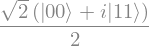

In [3]:
psi = (Qubit('00') + i * Qubit('11')) / sqrt2
psi

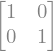

In [4]:
C = Matrix([
    [1, 0],
    [0, 1],
])
C

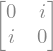

In [5]:
D = Matrix([
    [0, i],
    [i, 0],
])
D

#### Payoff matrix

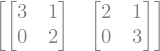

In [6]:
payoff_matrix = Array([
    [
        [3, 1],
        [0, 2],
    ],
    [
        [2, 1],
        [0, 3],
    ],
])
payoff_matrix

#### Pauli matrices  

In [7]:
I= Matrix([
    [1, 0],
    [0, 1],
])

In [8]:
X= Matrix([
    [0, 1],
    [1, 0],
])

In [9]:
Y= Matrix([
    [0, -i],
    [i, 0],
])

In [10]:
Z=Matrix([
    [1, 0],
    [0, -1],
])

#### Player strategies

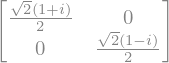

In [11]:
U3 = (I+i*Z)/ sqrt2
U3

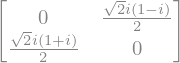

In [12]:
U4 = i*(X+Y)/sqrt2
U4

### (iX, iX) strategy - symbolic execution step by step

In [13]:
alice=i*Z
bob=I

In [14]:
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
ewl

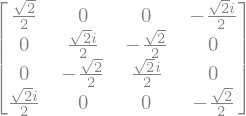

In [15]:
ewl.J

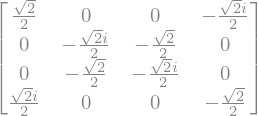

In [16]:
ewl.J_H

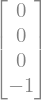

In [17]:
ewl.amplitudes(simplify=False)

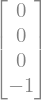

In [18]:
ewl.amplitudes()

In [19]:
ewl.probs()

In [20]:
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))

#### Different strategies test
$$
\begin{array}{c|cccc}
 & I & iX & U_3 & U_4 \\
\hline
I & (3,2) & (1,1) & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) \\
iX & (0,0) & (2,3) & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{5},\frac{5}{5}\right) \\
U_3 & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) & (2,3) & (0,0) \\
U_4 & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{2},\frac{5}{2}\right) & (1,1) & (3,2) \\
\end{array}
$$

In [21]:
alice=i*Z
bob=I
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))


#### Probabilities

In [22]:
ewl.probs()

### Statevector simulator IBM

In [23]:
from ewl.ibmq import EWL_IBMQ
ewl_ibmq = EWL_IBMQ(ewl)
ewl_ibmq

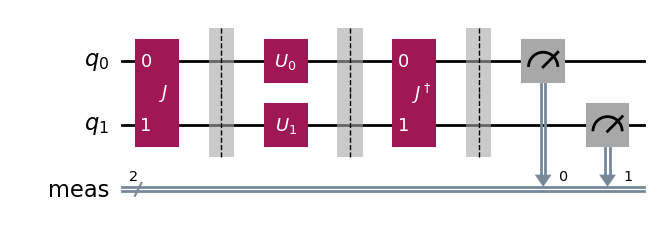

In [24]:
ewl_ibmq.draw()


{np.str_('11'): np.float64(1.0)}


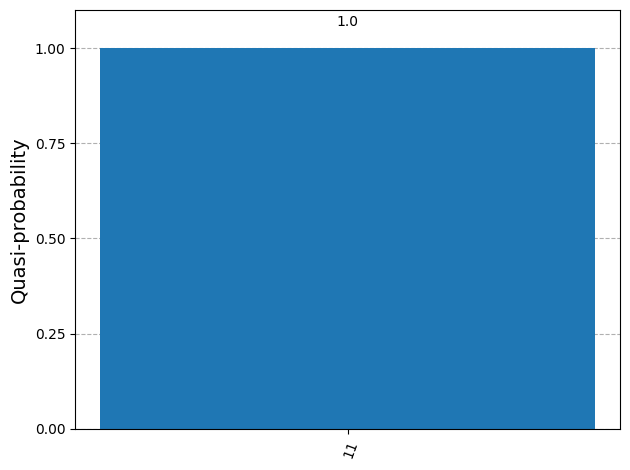

In [25]:
probs = ewl_ibmq.simulate_probs()
print(probs)
plot_histogram(probs)

{np.str_('11'): np.int64(1024)}


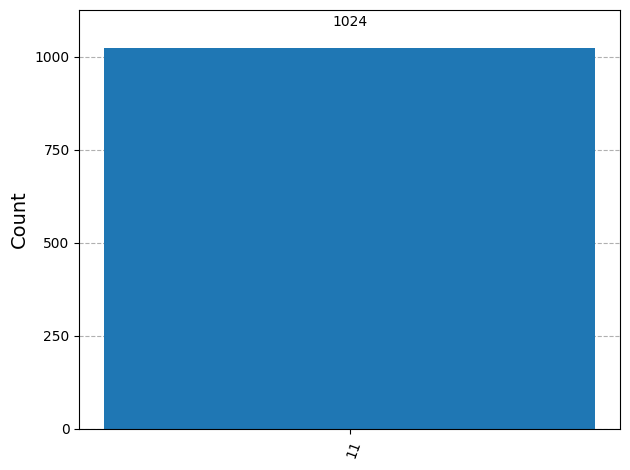

In [26]:
counts_qasm_simulator = ewl_ibmq.simulate_counts()
print(counts_qasm_simulator)
plot_histogram(counts_qasm_simulator)

### Transpiled circuit preview

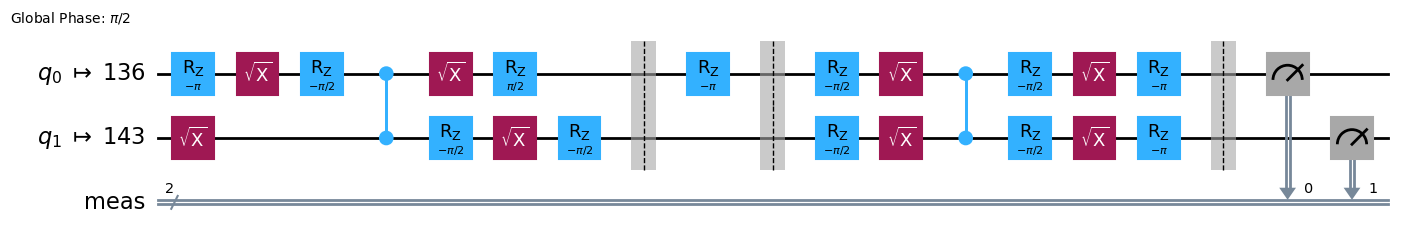

In [27]:
ewl_ibmq.draw_transpiled(backend_name='ibm_fez', optimization_level=3, fold=-1)

### Actual Run

In [28]:
counts_quantum_device = ewl_ibmq.run(tries=100)
print(counts_quantum_device)
#plot_histogram(counts_quantum_device)

[{'11': 973, '01': 28, '10': 21, '00': 2}, {'11': 961, '01': 34, '10': 27, '00': 2}, {'11': 993, '01': 21, '10': 9, '00': 1}, {'11': 984, '01': 24, '10': 16}, {'11': 978, '01': 29, '00': 5, '10': 12}, {'11': 986, '01': 24, '10': 12, '00': 2}, {'11': 971, '00': 4, '01': 28, '10': 21}, {'11': 983, '01': 24, '10': 14, '00': 3}, {'11': 981, '00': 3, '01': 24, '10': 16}, {'11': 983, '10': 11, '01': 28, '00': 2}, {'11': 972, '01': 28, '10': 21, '00': 3}, {'11': 975, '01': 31, '10': 16, '00': 2}, {'11': 975, '10': 11, '01': 33, '00': 5}, {'11': 976, '01': 32, '10': 16}, {'11': 980, '01': 22, '10': 20, '00': 2}, {'11': 988, '01': 23, '10': 10, '00': 3}, {'11': 981, '01': 26, '10': 13, '00': 4}, {'11': 975, '01': 30, '10': 18, '00': 1}, {'11': 986, '10': 11, '01': 25, '00': 2}, {'11': 976, '01': 27, '10': 18, '00': 3}, {'11': 990, '01': 22, '10': 9, '00': 3}, {'11': 988, '10': 10, '01': 26}, {'11': 974, '01': 31, '10': 16, '00': 3}, {'11': 974, '01': 37, '10': 12, '00': 1}, {'11': 975, '10': 15

In [29]:
with open('wyniki_iZI.txt', 'w') as plik:
    for element in counts_quantum_device:
        plik.write(str(dict(sorted(element.items()))) + '\n')

In [ ]:
binary_prob = [probs, counts_qasm_simulator, counts_quantum_device]
plot_histogram(
    binary_prob,
    bar_labels=False,
    legend=['ideal distribution', 'simulator (sampling)', 'real quantum device']       
)